# Employee Health Risk Analysis and Cholesterol Modeling

## Project Summary
This notebook investigates which health and demographic factors most strongly relate to total cholesterol in an employee wellness dataset. The work emphasizes structured EDA, anomaly correction, feature engineering, and a Random Forest feature-importance pass to rank the main drivers of cholesterol variation.

## Tech Stack
- pandas
- NumPy
- scikit-learn
- seaborn
- Matplotlib

## Dataset Scope
- `1,336` employee records
- `15` original variables spanning demographics, blood pressure, BMI, glucose, triglycerides, fat metrics, and employment duration


## Problem Framing
The objective is to understand which measurable health indicators are most associated with total cholesterol. Instead of jumping directly into a model, the notebook first performs extensive validation and correction so downstream analysis is not distorted by obvious data-entry issues.


### **1.3 Objectives**

Our primary objective is to unravel the complex interplay between various health factors and their association with CT levels. To achieve this goal, we will delve into the following steps:

1. **Descriptive Statistics**: Begin by exploring the characteristics of each variable through descriptive statistics, providing a comprehensive understanding of the data distribution and identifying potential patterns.

2. **Correlation Analysis**: Delve into the relationships between variables by calculating correlation coefficients. This will shed light on the strength and direction of associations between CT levels and other health indicators.

3. **Modeling CT Levels**: Employ machine learning techniques to construct predictive models that estimate CT levels based on the other measured variables. This will enable us to quantify the impact of each factor on CT levels.

4. **Identifying Key Determinants**: Uncover the most influential factors affecting CT levels by analyzing the results of the predictive models. This will provide valuable insights into targeted interventions to improve employee health.

5. **Interpretation and Implications**: Interpret the findings from the modeling process, drawing meaningful conclusions and highlighting the practical implications for employee health management.


In [13]:
data.head()


,Responden,Jenis Kelamin,Usia,Tekanan darah (S),Tekanan darah (D),Tinggi badan (cm),Berat badan (kg),IMT (kg/m2),Lingkar perut (cm),Glukosa Puasa (mg/dL),Cholesterol Total (mg/dL),Trigliserida (mg/dL),Fat,Visceral Fat,Masa Kerja,Tempat lahir
0,1,M,19.0,126.0,88.0,172.5,49.5,16.53,66.0,84.0,187.0,99.0,26.4,6.0,0.97,Purworejo
1,2,M,19.0,120.0,80.0,158.0,53.6,21.50,71.0,84.0,187.0,99.0,26.4,6.0,0.60,Bogor
2,3,M,19.0,120.0,80.0,170.0,59.5,20.59,80.0,80.0,187.0,99.0,26.4,6.0,1.37,bandung
3,4,F,19.0,100.0,70.0,149.0,45.1,20.31,62.0,81.0,187.0,99.0,30.5,3.5,1.00,Jakarta
4,5,M,19.0,110.0,70.0,171.6,62.4,21.19,78.0,84.0,187.0,99.0,26.4,6.0,4.00,Teluk Betung


In [15]:
data.describe()


,Responden,Usia,Tekanan darah (S),Tekanan darah (D),Tinggi badan (cm),Berat badan (kg),IMT (kg/m2),Lingkar perut (cm),Glukosa Puasa (mg/dL),Cholesterol Total (mg/dL),Trigliserida (mg/dL),Fat,Visceral Fat,Masa Kerja
count,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000
mean,670.000000,28.597461,113.147872,74.009709,164.940851,64.620500,23.693727,80.441972,84.571322,187.995519,106.982823,26.203510,6.231367,6.401837
std,386.680316,4.767230,10.164592,7.718752,7.386617,12.799096,4.021585,10.688215,11.522057,21.104834,44.143456,3.678467,2.431923,4.554438
min,1.000000,19.000000,80.000000,58.000000,138.500000,38.500000,14.850000,54.000000,65.000000,103.000000,34.000000,5.800000,0.500000,0.000000
25%,335.500000,25.000000,110.000000,70.000000,160.000000,55.275000,20.855000,72.000000,84.000000,187.000000,99.000000,26.400000,6.000000,4.000000
50%,670.000000,28.000000,110.000000,72.000000,165.000000,62.500000,23.200000,80.000000,84.000000,187.000000,99.000000,26.400000,6.000000,6.000000
75%,1004.500000,31.000000,120.000000,80.000000,170.000000,71.775000,26.000000,87.000000,84.000000,187.000000,99.000000,26.400000,6.000000,8.000000
max,1339.000000,39.000000,170.000000,100.000000,187.500000,139.750000,44.100000,128.000000,321.000000,308.000000,634.000000,40.900000,23.000000,31.000000


## Data Quality Review
The notebook audits multiple columns for implausible values and inconsistent relationships, then applies targeted corrections before any feature analysis.


In [22]:
def check_usia(dataframe):
    anomalies = []
    for index, row in dataframe.iterrows():
        if row['Usia'] < 21 or row['Usia'] > 65:
            anomalies.append((index, row['Usia']))
    return anomalies

# Check for anomalies in 'Usia'
anomalies_usia = check_usia(data)

# Print anomalies
if anomalies_usia:
    print("Anomalies found in 'Usia':")
    for index, value in anomalies_usia:
        print("Index {}: Age out of range = {}".format(index, value))
else:
    print("No anomalies found in 'Usia' (age within range 21-65).")


Detected age anomalies below the expected 21-65 range, then normalized those records for consistency.


In [32]:
def check_imt(dataframe):
    mistakes = []
    for index, row in dataframe.iterrows():
        berat_badan = row['Berat badan (kg)']
        tinggi_badan_cm = row['Tinggi badan (cm)']
        imt_calculated = berat_badan / ((tinggi_badan_cm / 100) ** 2)  # Convert height to meters

        imt_actual = row['IMT (kg/m2)']

        # Compare calculated IMT with actual IMT
        if abs(imt_calculated - imt_actual) < 2:  # Ignore differences greater than 2
            continue

        mistakes.append((index, imt_calculated, imt_actual))

    return mistakes

# Check for mistakes in "IMT (kg/m2)"
mistakes_imt = check_imt(data)

# Print mistakes
if mistakes_imt:
    print("Potential mistakes found in 'IMT (kg/m2)':")
    for index, calculated_imt, actual_imt in mistakes_imt:
        print("Index {}: Calculated IMT = {:.2f}, Actual IMT = {:.2f}".format(index, calculated_imt, actual_imt))
else:
    print("No potential mistakes found in 'IMT (kg/m2)'.")


Flagged BMI records where calculated and stored IMT diverged materially, then imputed the inconsistent cases with recalculated values.


In [45]:
def check_anomaly_masa_kerja(dataframe):
    anomalies = []
    for index, row in dataframe.iterrows():
        usia = row['Usia']
        masa_kerja = row['Masa Kerja']
        difference = usia - masa_kerja
        if masa_kerja != 0 and difference < 15:
            anomalies.append((index, usia, masa_kerja, difference))
    return anomalies

# Check for anomalies in "Masa Kerja"
anomalies_masa_kerja = check_anomaly_masa_kerja(data)

# Print anomalies
if anomalies_masa_kerja:
    print("Potential anomalies found in 'Masa Kerja':")
    for index, usia, masa_kerja, difference in anomalies_masa_kerja:
        print("Index {}: Usia = {}, Masa Kerja = {}, Difference = {}".format(index, usia, masa_kerja, difference))
else:
    print("No potential anomalies found in 'Masa Kerja'.")


Reviewed unrealistic combinations of age and employment duration, then corrected rows where tenure values likely reflected entry mistakes.


## Feature Engineering
After cleaning, the notebook derives binned demographic features, BMI-category indicators, geospatial birthplace coordinates, and interaction terms such as BMI-blood pressure products and age-triglyceride combinations.


In [54]:
def bin_n_dump(df):
    df["X1(1)"] = pd.cut(df["Usia"], [0,36,51,float('inf')], labels = [0,1,2])
    df.loc[df["X1(1)"] == 2, "X1(1)"] = 0
    df["X1(2)"] = pd.cut(df["Usia"], [0,51,66,float('inf')], labels = [0,1,2])
    df.loc[df["X1(2)"] == 2, "X1(2)"] = 0

    df["X2(1)"] = df["Jenis Kelamin"].replace({"F" : 0, "M" : 1})

    return df

def bin_imt(df):
    df['imt_category'] = pd.cut(df['IMT (kg/m2)'], bins=[-float('inf'), 18.4, 25.0, 27.0, float('inf')], labels=False)

    df['X3(1)'] = 0
    df['X3(2)'] = 0
    df['X3(3)'] = 0

    df.loc[df['imt_category'] == 1, 'X3(1)'] = 1
    df.loc[df['imt_category'] == 2, 'X3(2)'] = 1
    df.loc[df['imt_category'] == 3, 'X3(3)'] = 1

    df.drop(columns = ['imt_category'], inplace = True)
    return df

def binning(df):
    return bin_imt(bin_n_dump(df))


In [60]:
def create_new_features(df):
    # Ensure the column names here match exactly what's in your DataFrame
    df['BMI_SysBP'] = df['IMT (kg/m2)'] * df['Tekanan darah  (S)']
    df['BMI_Fat'] = df['IMT (kg/m2)'] * df['Fat']
    df['BMI_DiaBP'] = df['IMT (kg/m2)'] * df['Tekanan darah  (D)']
    df['Usia_BMI'] = df['Usia'] * df['IMT (kg/m2)']
    df['SysBP_DiaBP'] = df['Tekanan darah  (S)'] * df['Tekanan darah  (D)']
    df['Age_Fat'] = df['Usia'] * df['Fat']
    df['Age_squared'] = df['Usia'] ** 2
    df['trigliserida_div_age'] = df['Trigliserida (mg/dL)'] / df['Usia']
    df['age_x_trigliserida'] = df['Usia'] * df['Trigliserida (mg/dL)']
    df['trigliserida_x_bmi'] = df['Trigliserida (mg/dL)'] * df['IMT (kg/m2)']

    # Additional transformations
    df['log_trigliserida'] = np.log(df['Trigliserida (mg/dL)'] + 1)  # Log transform to normalize distribution
    df['squared_trigliserida'] = df['Trigliserida (mg/dL)'] ** 2  # Square transform
    df['inverse_trigliserida'] = 1 / (df['Trigliserida (mg/dL)'] + 1)  # Inverse transform
    return df

data = create_new_features(data)


## Modeling and Importance Analysis
A Random Forest regressor is used as a compact, interpretable baseline to estimate cholesterol and surface the most influential engineered features.


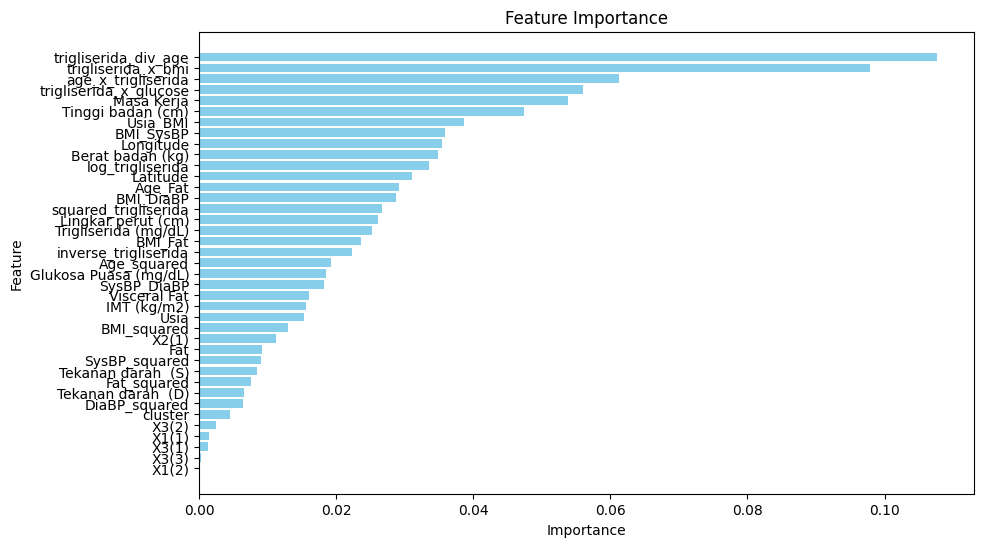

In [68]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# Preprocess your data (handle missing values, encode categorical variables, etc.)
# For simplicity, let's assume your features are in X and your target variable is in y
X = data.drop(columns=['Cholesterol Total (mg/dL)'])  # Assuming 'CT' is your target variable
y = data['Cholesterol Total (mg/dL)']

# Train a Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)  # You can adjust parameters as needed
model.fit(X, y)

# Get feature importances
feature_importances = model.feature_importances_

# Create a DataFrame to visualize feature importances
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important feature on top
plt.show()


## Visual Exploration
The notebook closes with distribution plots and relationship views that connect age, BMI, and cholesterol patterns back to the cleaned feature space.


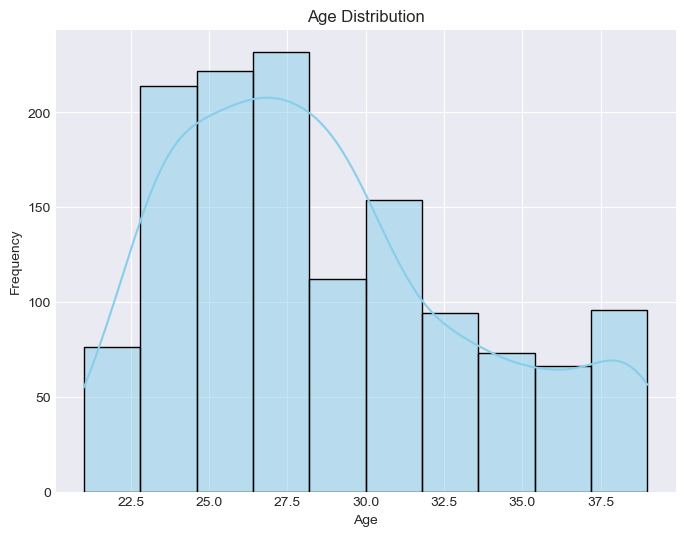

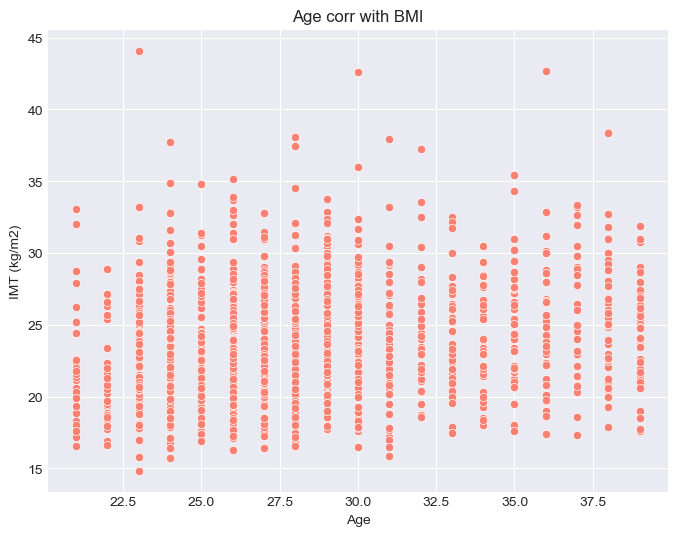

In [73]:
plt.figure(figsize=(8, 6))
sns.histplot(data["Usia"], bins=10, kde=True, color='skyblue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# Plotting age vs BMI
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data["Usia"], y=data["IMT (kg/m2)"], color='salmon')
plt.title('Age corr with BMI')
plt.xlabel('Age')
plt.ylabel('IMT (kg/m2)')
plt.show()

# Memotong data menjadi beberapa bins untuk Usia dan IMT (BMI)

# Menampilkan tinggi rata-rata tertinggi di chart


average_IMT_by_age = data.groupby('Usia')['IMT (kg/m2)'].mean()

plt.figure(figsize=(10, 6))
plt.plot(average_IMT_by_age.index, average_IMT_by_age.values, marker='o', color='skyblue')
plt.title('Average IMT with age')
plt.xlabel('Umur')
plt.ylabel('IMT (kg/m2)')
plt.grid(True)
plt.show()

# Membuat DataFrame dari hasil pengelompokan
df = pd.DataFrame({'Umur':average_IMT_by_age.index, 'IMT (kg/m2)': average_IMT_by_age.values})

# Menampilkan DataFrame sebagai tabel
print(df)


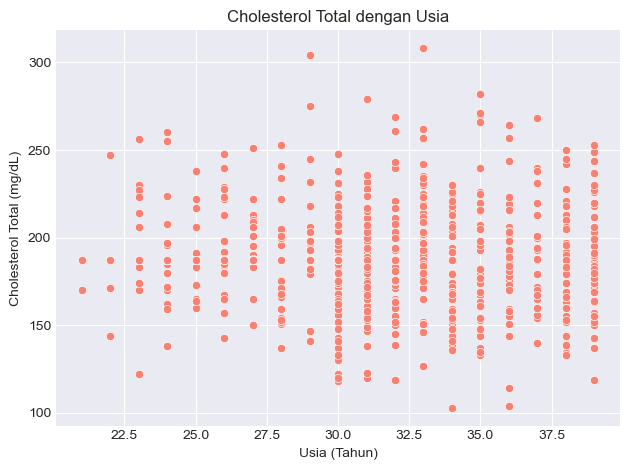

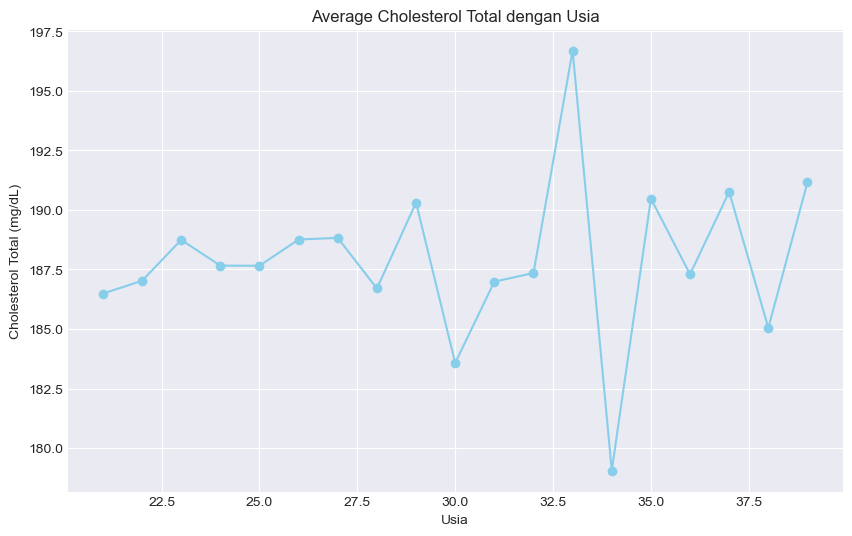

In [79]:
plt.subplot(1, 1, 1)
sns.scatterplot(x=data['Usia'], y=data["Cholesterol Total (mg/dL)"], color='salmon')
plt.title('Cholesterol Total dengan Usia')
plt.xlabel('Usia (Tahun)')
plt.ylabel('Cholesterol Total (mg/dL)')

plt.tight_layout()
plt.show()

average_cholesterol_by_age = data.groupby('Usia')['Cholesterol Total (mg/dL)'].mean()

plt.figure(figsize=(10, 6))
plt.plot(average_cholesterol_by_age.index, average_cholesterol_by_age.values, marker='o', color='skyblue')
plt.title('Average Cholesterol Total dengan Usia')
plt.xlabel('Usia')
plt.ylabel('Cholesterol Total (mg/dL)')
plt.grid(True)
plt.show()

# Membuat DataFrame dari hasil pengelompokan
df = pd.DataFrame({'Usia':average_cholesterol_by_age.index, 'Cholesterol Total (mg/dL)': average_cholesterol_by_age.values})

# Menampilkan DataFrame sebagai tabel
print(df)


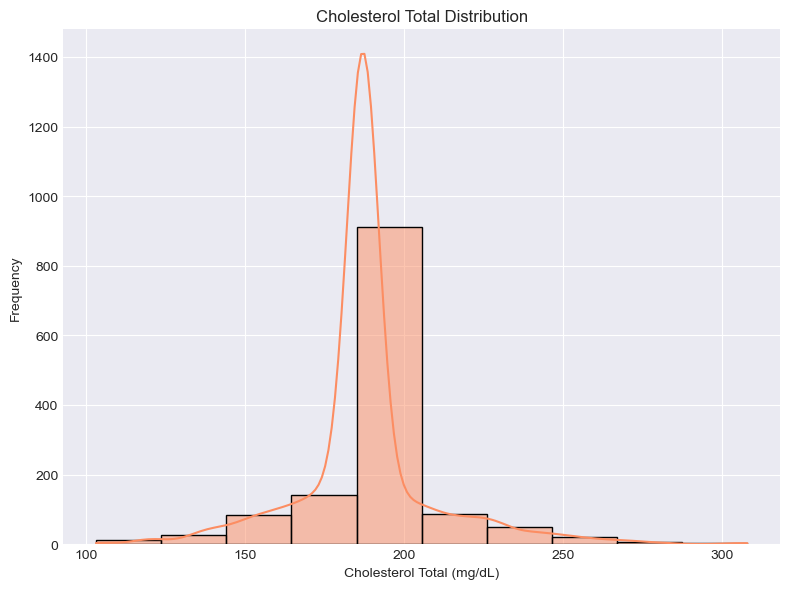

In [83]:
plt.figure(figsize=(8, 6))
sns.histplot(data['Cholesterol Total (mg/dL)'], bins=10, kde=True, color='#fc8d62')
plt.title('Cholesterol Total Distribution')
plt.xlabel('Cholesterol Total (mg/dL)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
